# Construire un modèle GSM pour un problème élastoplastique et faire son identification sur les données précédentes

In [1]:
import jax
jax.config.update("jax_platform_name","gpu")
jax.config.update("jax_enable_x64", True)


In [2]:
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jaxmat
import jaxmat.materials as jm
from jaxmat.loader import ImposedLoading, global_solve,solver, adjoint, residual
from jaxmat.tensors import SymmetricTensor2, dev, main_invariants
from sklearn.metrics import r2_score
from jaxmat.utils import partition_by_node_names
import numpy as np
from jaxmat.state import AbstractState, make_batched
import optax
import optimistix as optx
from jaxmat.nn.icnn import HomogeneousICNN, ICNN     
from optax.tree_utils import tree_scale, tree_sub

In [3]:
class LinearHardening(eqx.Module):
    sig0: jax.Array = eqx.field(converter=lambda x: jnp.asarray(x, dtype=jnp.float64))  # Limite d'élasticité (MPa)
    H: jax.Array = eqx.field(converter=lambda x: jnp.asarray(x, dtype=jnp.float64))      # Module d'écrouissage (MPa)
    
    def __call__(self, p):
        return self.sig0 + self.H * p

Nsteps = 200
sec1 = jnp.linspace(0, -0.05, Nsteps)   # 1ere charge en compression
sec2 = jnp.linspace(-0.05, 0, Nsteps)   # 1ere décharge
sec3 = jnp.linspace(0, -0.08, Nsteps)   # 2nd charge en compression

imposed_eps_path = jnp.concatenate([sec1, sec2[1:],sec3[1:]])
H_max = 20e3
E=70e3
nu=0.33
sig0=300
H=5e3


elasticity = jm.LinearElasticIsotropic(E=E, nu=nu)
hardening = LinearHardening(sig0=sig0, H=H)
material = jm.vonMisesIsotropicHardening(elasticity=elasticity, yield_stress=hardening)

/tmp/ipykernel_3171173/2228096902.py:23: UserWarning: Using `field(init=False)` on `equinox.Module` can lead to surprising behaviour when used around `jax.grad`. In the following example, observe how JAX computes gradients with respect to the `.len` attribute (which is a PyTree leaf passed across the `jax.grad` boundary) and that there are no gradients with respect to `.a` or `.b`:

```
import equinox as eqx
import jax
import jax.numpy as jnp

class Foo(eqx.Module):
    a: jax.Array
    b: jax.Array
    len: jax.Array = eqx.field(init=False)

    def __post_init__(self):
        self.len = jnp.sqrt(self.a**2 + self.b**2)

    def __call__(self, x):
        return self.len * x

@jax.jit
@jax.grad
def call(module, x):
    return module(x)

grads = call(Foo(jnp.array(3.0), jnp.array(4.0)), 5)
# Foo(
#   a=Array(0., dtype=float32, weak_type=True),
#   b=Array(0., dtype=float32, weak_type=True),
#   len=Array(5., dtype=float32, weak_type=True)
# )
```
  material = jm.vonMisesIsotropicHarden

## I. Construction des données "expérimentales"

In [15]:
dt = 0.1 * jnp.ones(len(imposed_eps_path))  # indépendant du temps

@eqx.filter_jit
def compute_evolution(material, eps_path, dt):
    """Intègre la loi sur le chemin eps_path (chargement mixte).
    Retourne σ_xx à chaque pas. Différentiable par rapport aux paramètres."""
    state0 = material.init_state(1)
    def step(carry, eps_xx_val):
        Eps, state = carry
        loading = ImposedLoading(
            epsxx=jnp.ones(1) * eps_xx_val,
            sigyy=jnp.zeros(1),
            sigzz=jnp.zeros(1),
        )
        Eps_new, state_new, _ = global_solve(Eps, state, loading, material, dt)
        return (Eps_new, state_new), state_new.stress[0, 0, 0]
    _, sig = jax.lax.scan(step, (state0.strain, state0), eps_path)
    return sig

sig = compute_evolution(material, imposed_eps_path, dt)


In [24]:
sig_max, eps_max = np.abs(sig).max(), np.abs(imposed_eps_path).max()
E_max = sig_max / eps_max

n_eps, n_sig = imposed_eps_path / imposed_eps_path.max(), sig / sig.max()

In [25]:
print(f"E={E/E_max}", f"E_norm = {E / sig_max * eps_max}")

E=5.826499784203135 E_norm = 5.8264997842031345


## II. Variables internes

In [26]:
class InternalState(AbstractState):
    """
    Internal state for hardening viscoplasticity
    """

    p: jax.Array = eqx.field(init=False)
    """scalar """
    epsp: SymmetricTensor2 = eqx.field(default_factory=lambda: SymmetricTensor2())
    """Plastic strain tensor"""
    Nvar: int = eqx.field(static=True, default=1)

    def __post_init__(self):
        # Initialise to zero
        self.p = jnp.zeros((self.Nvar,))


int_var = InternalState(Nvar=1)  # I use 1 additional scalar variable.
print(int_var)

InternalState(p=f64[1], epsp=SymmetricTensor2(_array=f64[6]))


/tmp/ipykernel_3171173/1775434363.py:17: UserWarning: Using `field(init=False)` on `equinox.Module` can lead to surprising behaviour when used around `jax.grad`. In the following example, observe how JAX computes gradients with respect to the `.len` attribute (which is a PyTree leaf passed across the `jax.grad` boundary) and that there are no gradients with respect to `.a` or `.b`:

```
import equinox as eqx
import jax
import jax.numpy as jnp

class Foo(eqx.Module):
    a: jax.Array
    b: jax.Array
    len: jax.Array = eqx.field(init=False)

    def __post_init__(self):
        self.len = jnp.sqrt(self.a**2 + self.b**2)

    def __call__(self, x):
        return self.len * x

@jax.jit
@jax.grad
def call(module, x):
    return module(x)

grads = call(Foo(jnp.array(3.0), jnp.array(4.0)), 5)
# Foo(
#   a=Array(0., dtype=float32, weak_type=True),
#   b=Array(0., dtype=float32, weak_type=True),
#   len=Array(5., dtype=float32, weak_type=True)
# )
```
  int_var = InternalState(Nvar=1)  # I 

## III. L'énergie libre $\psi$

L'énergie libre de Helmotz dans le cas élastoplastique se décompose en une partie élastique et une partie écrouissage : 

$\psi(\epsilon,\epsilon_p,p)= \frac{1}{2} (\epsilon - \epsilon_p ): \mathbb{C} : (\epsilon - \epsilon_p ) + \frac{1}{2}Hp² ~$ ou $~\psi(\epsilon,\epsilon_p,p)= \frac{1}{2} (\epsilon - \epsilon_p ): \mathbb{C} : (\epsilon - \epsilon_p ) + N_{ICNN}(p) $

In [27]:
class FreeEnergy(eqx.Module):
    elasticity: jm.AbstractLinearElastic  # Hooke isotrope
    nn_anelastic: ICNN  # ICNN for epsp variable
    nn_hardening: ICNN  # ICNN for p variable

    def __call__(self, eps, isv):
        """
        Compute free energy:
        psi = 0.5*(eps - sum_i alpha_p[i]) : C : (eps - sum_i alpha_p[i]) + NN(epsp) + NN(q)
        """
        epsp = isv.epsp
        psi_elastic = 0.5 * jnp.trace((eps - epsp) @ (self.elasticity.C @ (eps - epsp)))

        _, I2, _ = main_invariants(isv.epsp)
        psi_anelastic = self.nn_anelastic(I2)
        psi_hardening = self.nn_hardening(isv.p)

        # énergie totale
        return psi_elastic + psi_hardening + psi_anelastic

## IV. Le potentiel de dissipation dual $\phi*$

On défini : $Φ{(\dot\epsilon_p,\dot p​)} = N_{ICNN​}(q,\dot p) ~~$ avec $ q=tr(dev(\dot\epsilon_p))  $

In [28]:
class ICNNDissipationPotential(ICNN):
    def icnn_potential(self, A, Q=None):
        """
        A : SymmetricTensor2 (batch Nvar, 3,3)
        Q : jnp.ndarray (batch Nvar,) ou None
        """
        # Calcul invariants principaux du batch de A
        # I1, I2, I3 = jax.vmap(main_invariants)(A)  # shape (Nvar,)
        I1, I2, I3 = main_invariants(A)
        # Construit l'entrée du réseau
        if Q is not None:
            I2 = jnp.atleast_1d(I2)
            Q  = jnp.atleast_1d(Q)
            x = jnp.concatenate([I2, Q])
        else:
            x = I2
        return super().__call__(x)

    def __call__(self, isv):
        """
        isv: objet avec
            .A : SymmetricTensor2 (forces sur alpha_p)
            .Q : jnp.ndarray (forces sur q)
        """
        A_p = isv.epsp.tensor       
        Q = isv.p       

        # Potentiel pseudo-dissipatif dual
        return (
            self.icnn_potential(A_p, Q)
            - jax.jvp(
                lambda a: self.icnn_potential(SymmetricTensor2(tensor=a), Q=jnp.zeros_like(Q)),
                (jnp.zeros_like(A_p),),
                (A_p,),
            )[1]
        )

## V. Assemblage et compilation

In [29]:
from abc import abstractmethod
import jaxmat.materials as jm
import equinox as eqx
import lineax as lx
from jaxmat.solvers import NewtonTrustRegion
from optax.tree_utils import tree_add, tree_zeros_like, tree_scale, tree_sub
import jax
import optimistix as optx

class GeneralizedStandardMaterialDual(jm.SmallStrainBehavior):
    r"""
    GSM where internal variables evolve by solving the implicit equation with an optax solver.

    dot(alpha) = dPhi_star_dA( A_dis ), with A_dis = - dPsi/dalpha

    Attributes:
        free_energy: eqx.Module, Psi(eps, alpha) -> scalar or tensor
        dual_dissipation: eqx.Module, Phi^*(A_dis) -> scalar (or differentiable scalar-like)
    """

    free_energy: eqx.Module
    r"""Module defining the Helmholtz free energy $\Psi(\beps,\balpha)"""
    dual_dissipation_potential: eqx.Module
    r"""Module defining the dual dissipation pseudo-potential $Phi^*(A_dis)$"""
    minimisation_solver = NewtonTrustRegion(
        rtol=1e-6, atol=1e-6, linear_solver=lx.AutoLinearSolver(well_posed=False)
    )

    @abstractmethod
    def make_internal_state(self):
        """Create internal state variables."""
        pass

    def residual(self, d_isv, args):
        r"""
        Residual of the implicit evolution equation for internal variables.

        Parameters
        ----------
        d_isv : PyTree
            Increment of internal variables Delta alpha.
        args : tuple
            (eps, state, dt)
        """
        eps, state, dt = args
        isv_old = state.internal
        isv = tree_add(isv_old, d_isv)  # alpha_{n+1}
        isv_dot = tree_scale(1.0 / dt, d_isv)

        # Dissipative force A_dis = - dPsi / dalpha
        A_dis = jax.jacfwd(self.free_energy, argnums=1)(eps, isv)
        A_dis = tree_scale(-1, A_dis)

        # Flow rule: dot(alpha) - dPhi*(A_dis) = 0
        flow = jax.grad(self.dual_dissipation_potential)(A_dis)

        return tree_sub(isv_dot, flow)

    def constitutive_update(self, eps, state, dt):
        isv_old = state.internal
        d_isv0 = tree_zeros_like(isv_old)
        args = eps, state, dt

        sol = optx.root_find(
            self.residual,
            solver=self.minimisation_solver,
            y0=d_isv0,
            args=args,
            throw=False,
        )

        d_isv = sol.value
        isv = tree_add(isv_old, d_isv)

        # Stress: sigma = dPsi / deps
        sig = jax.jacfwd(self.free_energy, argnums=0)(eps, isv)

        new_state = state.update(stress=sig, internal=isv)
        return sig, new_state

In [30]:
hidden_dims = [8,8] # (16,16,16)
Nvar = 1
key = jax.random.PRNGKey(42)
key1, key2, key3 = jax.random.split(key, num=3)  # define keys for reproducibility
nu = 0.33
elasticity = jm.LinearElasticIsotropic(E=E / E_max, nu=nu)

nn_anelastic = ICNN(1, hidden_dims, key1)  # one input the second main invariant
nn_hardening = ICNN(Nvar, hidden_dims, key2)  # Nvar inputs
free_energy = FreeEnergy(elasticity, nn_anelastic, nn_hardening)
icnn_corr = ICNN(Nvar + 1, hidden_dims, key3)
dissipation_potential = ICNNDissipationPotential(Nvar + 1, hidden_dims, key3)

class GSM(jm.GeneralizedStandardMaterialDual):
    def make_internal_state(self):
        return InternalState(Nvar=Nvar)

    
gsm = GSM(free_energy, dissipation_potential)
state0 = gsm.init_state()

/tmp/ipykernel_3171173/3154113540.py:19: UserWarning: Using `field(init=False)` on `equinox.Module` can lead to surprising behaviour when used around `jax.grad`. In the following example, observe how JAX computes gradients with respect to the `.len` attribute (which is a PyTree leaf passed across the `jax.grad` boundary) and that there are no gradients with respect to `.a` or `.b`:

```
import equinox as eqx
import jax
import jax.numpy as jnp

class Foo(eqx.Module):
    a: jax.Array
    b: jax.Array
    len: jax.Array = eqx.field(init=False)

    def __post_init__(self):
        self.len = jnp.sqrt(self.a**2 + self.b**2)

    def __call__(self, x):
        return self.len * x

@jax.jit
@jax.grad
def call(module, x):
    return module(x)

grads = call(Foo(jnp.array(3.0), jnp.array(4.0)), 5)
# Foo(
#   a=Array(0., dtype=float32, weak_type=True),
#   b=Array(0., dtype=float32, weak_type=True),
#   len=Array(5., dtype=float32, weak_type=True)
# )
```
  gsm = GSM(free_energy, dissipation_po

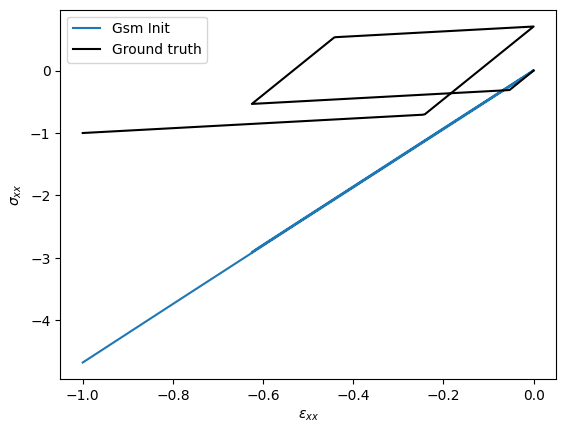

In [ ]:
import time

sig_init = compute_evolution(gsm, n_eps, dt)

plt.figure()
plt.plot(n_eps, sig_init, label="Gsm Init")
plt.plot(eps_tensor_hist[:,0,0,0], sig_tensor_hist[:,0,0,0], "-k", label="Ground truth")
plt.xlabel(r"$\epsilon_{xx}$")
plt.ylabel(r"$\sigma_{xx}$")
plt.legend()
plt.show()



In [14]:
eps_tensor_hist[:5,0,0,0], eps_tensor_hist[:5,0,1,1]/-0.33,eps_tensor_hist[:5,0,2,2]/-0.33

(Array([ 0.        , -0.0031407 , -0.00628141, -0.00942211, -0.01256281],      dtype=float64),
 Array([-0.        , -0.0031407 , -0.00628141, -0.00942211, -0.01256281],      dtype=float64),
 Array([-0.        , -0.0031407 , -0.00628141, -0.00942211, -0.01256281],      dtype=float64))

## VI. Entrainement

In [15]:
learning_rate = 1.5e-2  
max_steps = 300        
warmup_steps = max(5, max_steps // 15)


lr_schedule = optax.warmup_cosine_decay_schedule(  # comment varie le learning rate 
    init_value=learning_rate * 0.1,   
    peak_value=learning_rate,
    warmup_steps=warmup_steps,
    decay_steps=max_steps,
    end_value=learning_rate * 0.05,
)

optimizer = optax.chain(
    optax.scale_by_adam(),
    optax.scale_by_param_block_rms(),
    # optax.scale_by_schedule(lambda count: -lr_schedule(count)),
    optax.scale_by_learning_rate(learning_rate=learning_rate)
)

@eqx.filter_jit
def total_loss(params, args):
    static_, eps_path, sig= args
    mat = params if static_ is None else eqx.combine(params, static_)
    eps_, sig_ = simulate(mat, eps_path)
    data_loss = jnp.mean((sig_[:,0,0,0] - sig)**2)
    loss_val = data_loss 
    return loss_val, (sig_[:,0,0,0], data_loss)

# --- Gradient step ---
@eqx.filter_jit
def step(params, opt_state, args):
    (loss_val, (sig_hat, data_loss)), grads = eqx.filter_value_and_grad(total_loss, has_aux=True)(params, args)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = eqx.apply_updates(params, updates)
    return params, opt_state, loss_val, data_loss, sig_hat



In [ ]:
trainable_gsm_dual, static_gsm_dual = partition_by_node_names(
    gsm, ["free_energy.elasticity"]
)

params_dual = trainable_gsm_dual
opt_state_dual = optimizer.init(params_dual)

losses_dual = []
# H_history_dual = []
# E_history_dual =[]

for step_idx in range(max_steps):
    params_dual, opt_state_dual, loss_val, data_loss, sig_hat_train = step(
        params_dual, opt_state_dual, (static_gsm_dual, imposed_eps_path / eps_max, sig_tensor_hist[:,0,0,0])
    )
    jax.block_until_ready(sig_hat_train)
    losses_dual.append(float(loss_val))
    # H_history_dual.append(float(params_dual.free_energy.hardening.H))
    # E_history_dual.append(float(params_dual.free_energy.elasticity.E))
    if step_idx % 20 == 0:
        r2_now = r2_score(np.asarray(sig_tensor_hist[:,0,0,0]), np.asarray(sig_hat_train))
        print(f"Step {step_idx}: loss = {float(loss_val):.6e}  data_loss = {float(data_loss):.6e}  "
            f"R2_gt = {r2_now:.4f} ") #  E = {E_history_dual[-1]:.4f} H = {H_history_dual[-1]:.4f}
              

trained_material_gsm_dual = params_dual if static_gsm_dual is None else eqx.combine(params_dual, static_gsm_dual)

plt.figure()
plt.plot(losses_dual)
plt.xlabel("iteration"); plt.ylabel("loss"); plt.yscale("log")
plt.title("Convergence - modele dual")
plt.show()

# print(f"\nH identifie (dual) = {float(trained_material_gsm_dual.free_energy.hardening.H*H_max):.2f}")
# print("Vraie valeur H      = 5000.00")
# print(f"\nE identifie (dual) = {float(trained_material_gsm_dual.free_energy.elasticity.E*E_max):.2f}")
# print("Vraie valeur E      = 70000.00")

Step 0: loss = 3.180518e+00  data_loss = 3.180518e+00  R2_gt = -9.0975 


In [29]:
sig_tensor_hist[:,0,0,0].shape

(598,)

In [20]:
print(f"\nE identifie (dual) = {float(trained_material_gsm_dual.free_energy.elasticity.E*E_max):.2f}")
print("Vraie valeur E      = 70000.00")


E identifie (dual) = 541539.57
Vraie valeur E      = 70000.00


### Re-vérification de la cohérence thermodynamique après entraînement

In [16]:
phi_star_trained = trained_material_gsm_dual.dual_dissipation_potential

phi0_t, grad0_t = jax.value_and_grad(phi_star_trained)(zero_isv)
print(f"Phi*(0) apres entrainement            = {float(phi0_t):.3e}   (attendu : 0)")
print(f"max|grad Phi*(0)| apres entrainement  :  {float(jnp.abs(grad0_t.eps_p.tensor).max()) + float(jnp.abs(grad0_t.p)):.3e}   (attendu : 0)")

phi1_t = jax.vmap(phi_star_trained)(A1)
phi2_t = jax.vmap(phi_star_trained)(A2)
phi_mid_t = jax.vmap(phi_star_trained)(A_mid)
jensen_gap_t = t * phi1_t + (1 - t) * phi2_t - phi_mid_t
n_violations_t = int(jnp.sum(jensen_gap_t < -1e-8))
print(f"\nTest de convexite apres entrainement ({N_test} couples) : {n_violations_t} violation(s)   (attendu : 0)")
print(f"min(t*Phi1+(1-t)*Phi2 - Phi_mid) = {float(jensen_gap_t.min()):.3e}   (doit rester >= 0)")

Phi*(0) apres entrainement            = 0.000e+00   (attendu : 0)
max|grad Phi*(0)| apres entrainement  :  0.000e+00   (attendu : 0)

Test de convexite apres entrainement (500 couples) : 0 violation(s)   (attendu : 0)
min(t*Phi1+(1-t)*Phi2 - Phi_mid) = 3.267e-06   (doit rester >= 0)


### Qualité du fit

R2 (vs ground truth propre) = 0.6693 
R2 (vs donnees bruitees)    = 0.6704


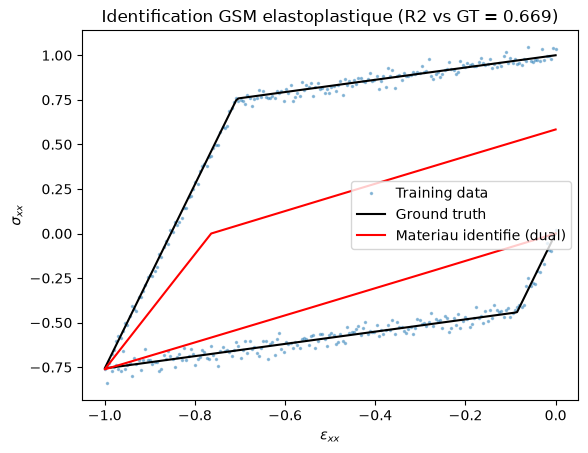

In [17]:
sig_pred_dual = compute_evolution(trained_material_gsm_dual, imposed_eps_path)

sig_pred_dual_np = np.asarray(sig_pred_dual)
sig_xx_np = np.asarray(sig_xx)
sigxx_exp_np = np.asarray(sigxx_exp)

r2_gt_dual = r2_score(sig_xx_np, sig_pred_dual_np)
r2_train_dual = r2_score(sigxx_exp_np, sig_pred_dual_np)
mse_gt_dual = float(np.mean((sig_pred_dual_np - sig_xx_np) ** 2))

print(f"R2 (vs ground truth propre) = {r2_gt_dual:.4f} ")
print(f"R2 (vs donnees bruitees)    = {r2_train_dual:.4f}")

plt.figure()
plt.plot(epsxx_exp, sigxx_exp, ".", ms=3, alpha=0.4, label="Training data")
plt.plot(eps_xx, sig_xx, "-k", label="Ground truth")
plt.plot(eps_xx, sig_pred_dual, "-r", label="Materiau identifie (dual)")
plt.xlabel(r"$\epsilon_{xx}$"); plt.ylabel(r"$\sigma_{xx}$")
plt.legend()
plt.title(f"Identification GSM elastoplastique (R2 vs GT = {r2_gt_dual:.3f})")
plt.show()

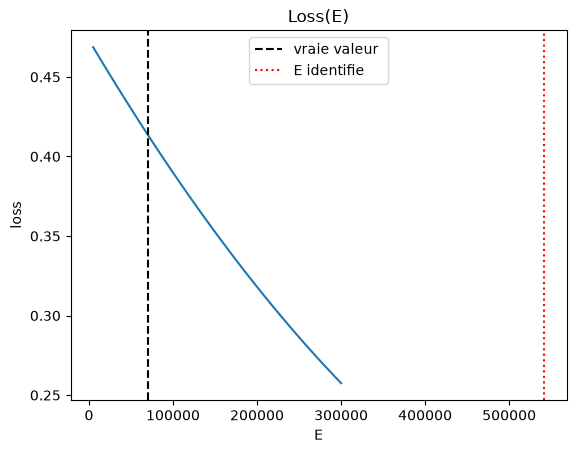

In [19]:
E_values = jnp.linspace(5000/E_max, 300e3/E_max, 30)

def loss_for_E(E_val, trained_material_gsm_dual):
    mat = trained_material_gsm_dual
    mat = eqx.tree_at(lambda m: m.free_energy.elasticity.E, mat, E_val)
    params_, static_ = eqx.partition(mat, eqx.is_array)
    loss_val, _ = total_loss(params_, (static_, imposed_eps_path, sigxx_exp, gamma1, gamma2))
    return loss_val

losses_E = [float(loss_for_E(E, trained_material_gsm_dual)) for E in E_values]  # params_dual = etat final entraine

plt.figure()
plt.plot(E_values * E_max, losses_E)
plt.axvline(70000, color="k", linestyle="--", label="vraie valeur ")
plt.axvline(float(trained_material_gsm_dual.free_energy.elasticity.E) * E_max,
            color="r", linestyle=":", label="E identifie ")
plt.xlabel("E"); plt.ylabel("loss"); plt.legend()
plt.title("Loss(E)")
plt.show()

## VIII. Simulation complète

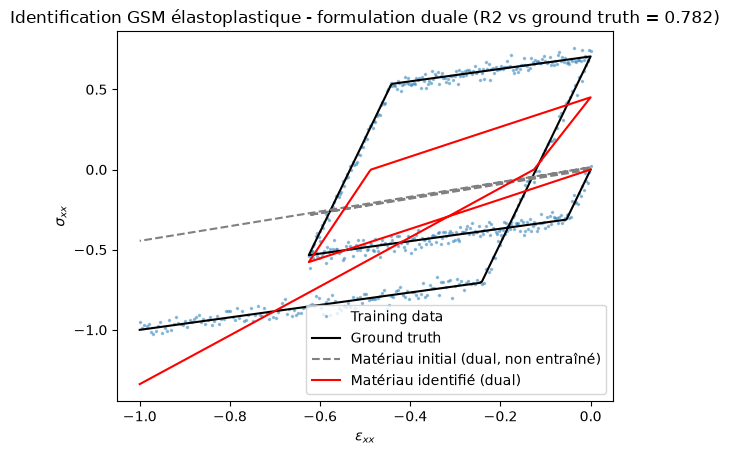

R2 final (vs ground truth) = 0.7820


In [ ]:
# Simulation avec le materiau identifie
sig_pred = compute_evolution(trained_material_gsm_dual, imposed_eps_path)

r2_final = r2_score(np.asarray(sig_xx), np.asarray(sig_pred))

plt.figure()
plt.plot(epsxx_exp, sigxx_exp, ".", ms=3, alpha=0.4, label="Training data")
plt.plot(eps_xx, sig_xx, "-k", label="Ground truth")
plt.plot(eps_xx, sig_init, "--", color="gray", label="Matériau initial (dual, non entraîné)")
plt.plot(eps_xx, sig_pred, "-r", label="Matériau identifié (dual)")
plt.xlabel(r"$\epsilon_{xx}$")
plt.ylabel(r"$\sigma_{xx}$")
plt.legend()
plt.title(f"Identification GSM élastoplastique - formulation duale (R2 vs ground truth = {r2_final:.3f})")
plt.show()

print(f"R2 final (vs ground truth) = {r2_final:.4f}")